In [35]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


sns.set()

In [36]:
df = pd.read_csv("synthetic_dataset.csv")
df.head()

,Category,Price,Rating,Stock,Discount
0,NaN,5548.0,1.870322,NaN,0.0
1,NaN,3045.0,4.757798,NaN,38.0
2,NaN,4004.0,NaN,In Stock,0.0
3,NaN,4808.0,1.492085,NaN,33.0
4,NaN,1817.0,NaN,Out of Stock,23.0


In [37]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4362 entries, 0 to 4361
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Category  1614 non-null   object 
 1   Price     4188 non-null   float64
 2   Rating    2312 non-null   float64
 3   Stock     3010 non-null   object 
 4   Discount  3970 non-null   float64
dtypes: float64(3), object(2)
memory usage: 170.5+ KB


,Price,Rating,Discount
count,4188.000000,2312.000000,3970.000000
mean,5016.970630,3.038293,24.516625
std,2839.984813,1.143074,14.347164
min,102.000000,1.000366,0.000000
25%,2628.250000,2.069490,12.000000
50%,4996.500000,3.082060,25.000000
75%,7418.000000,4.008620,37.000000
max,9999.000000,4.997818,49.000000


In [38]:
print(df.isna())

print(df.isna().sum())

      Category  Price  Rating  Stock  Discount
0         True  False   False   True     False
1         True  False   False   True     False
2         True  False    True  False     False
3         True  False   False   True     False
4         True  False    True  False     False
...        ...    ...     ...    ...       ...
4357      True  False   False   True     False
4358     False  False    True  False     False
4359      True  False    True  False     False
4360     False  False   False   True     False
4361      True   True   False   True     False

[4362 rows x 5 columns]
Category    2748
Price        174
Rating      2050
Stock       1352
Discount     392
dtype: int64


In [39]:

df.duplicated()[df.duplicated()==True]

,0
505,True
1746,True
1760,True
2051,True
2124,True
2241,True
3302,True
3314,True
3527,True
3553,True


In [40]:
df.duplicated().sum()

np.int64(15)

 finding number of rows and columns

In [41]:


print("Shape (rows, columns): ", df.shape,"\n")

print("number of rows: ", df.shape[0])
print("number of columns: ", df.shape[1])

Shape (rows, columns):  (4362, 5) 

number of rows:  4362
number of columns:  5


In [42]:
df.dtypes

,0
Category,object
Price,float64
Rating,float64
Stock,object
Discount,float64


# Data Cleaning

In [47]:


df.loc[:, 'Category'] = df['Category'].fillna('Unknown')


df.loc[:, 'Price'] = pd.to_numeric(df['Price'], errors='coerce')
df.loc[:, 'Price'] = df['Price'].fillna(df['Price'].median())


df.loc[:, 'Rating'] = pd.to_numeric(df['Rating'], errors='coerce')
df.loc[:, 'Rating'] = df['Rating'].fillna(df['Rating'].median())


df.loc[:, 'Stock'] = df['Stock'].fillna('Unknown')


df.loc[:, 'Discount'] = pd.to_numeric(df['Discount'], errors='coerce')
df.loc[:, 'Discount'] = df['Discount'].fillna(df['Discount'].median())


if 'Date' in df.columns:
    df.loc[:, 'Date'] = pd.to_datetime(df['Date'], errors='coerce')

if 'Amount' in df.columns:
    df.loc[:, 'Amount'] = df['Amount'].replace(r'[\$,]', '', regex=True)
    df.loc[:, 'Amount'] = pd.to_numeric(df['Amount'], errors='coerce')


df = df.drop_duplicates()




In [44]:

df['Stock'] = df['Stock'].fillna('Unknown')
df['Stock'] = df['Stock'].astype(str)

In [45]:
print(df['Stock'].dtypes)
print(df['Stock'].value_counts())

object
Stock
In Stock        1508
Out of Stock    1489
Unknown         1348
Name: count, dtype: int64


In [46]:
print(df.dtypes)

Category     object
Price       float64
Rating      float64
Stock        object
Discount    float64
dtype: object


To clean the dataset, I filled the missing values by replacing the Category with 'Unknown', Price, Rating, and Discount with their respective median values, and Stock with 'Unknown' for categorical consistency. I also converted the data types so that Price, Rating, and Discount are floats, while Stock and Category remain as objects. Additionally, I removed any duplicate rows to ensure the dataset was accurate. This cleaning was necessary because missing values can prevent accurate data analysis, duplicates can distort averages and other statistics, and incorrect data types can hinder proper numeric analysis and visualization.

# Descriptive summary Statistics

In [48]:
df.describe(include='all')

,Category,Price,Rating,Stock,Discount
count,4345,4345.000000,4345.000000,4345,4345.000000
unique,5,NaN,NaN,3,NaN
top,Unknown,NaN,NaN,In Stock,NaN
freq,2732,NaN,NaN,1508,NaN
mean,NaN,5016.230955,3.058771,NaN,24.558803
std,NaN,2788.194060,0.834024,NaN,13.686718
min,NaN,102.000000,1.000366,NaN,0.000000
25%,NaN,2735.000000,2.945174,NaN,14.000000
50%,NaN,4996.500000,3.082060,NaN,25.000000
75%,NaN,7316.000000,3.181728,NaN,36.000000




*   All missing values are now represented consistently.

*  Numeric columns are ready for statistical analysis.



*   Duplicate rows were removed to prevent misleading results.









**Price distribution**

Reveals pricing range and skewness.

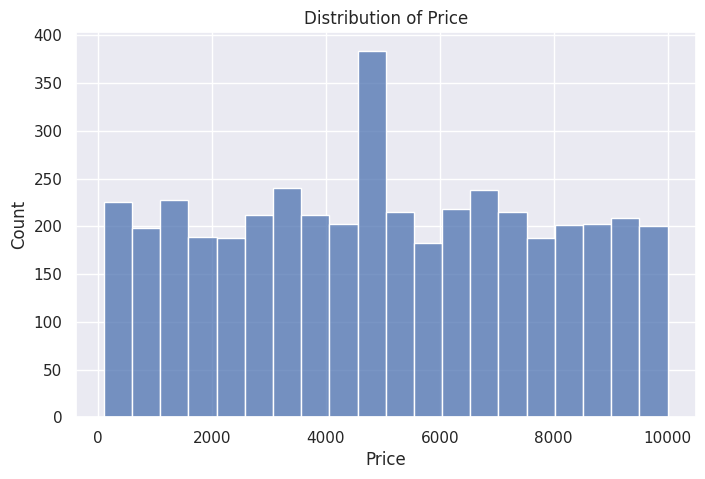

In [49]:

plt.figure(figsize=(8,5))
sns.histplot(df['Price'], bins=20)
plt.title("Distribution of Price")
plt.show()

**Rating distribution**

Understand product quality trends.

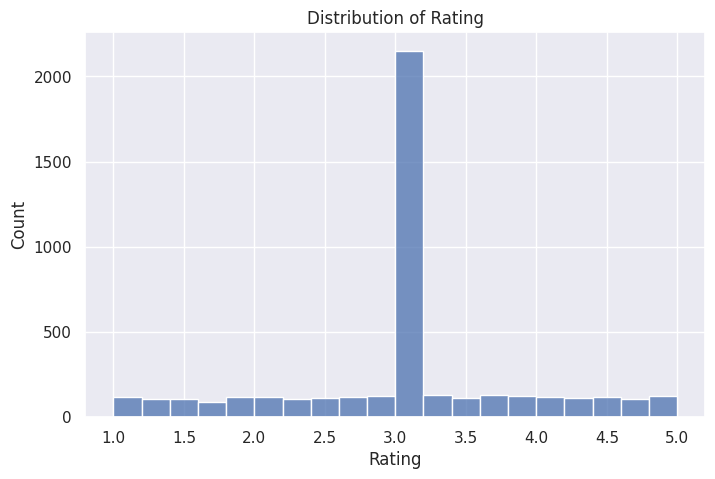

In [50]:

plt.figure(figsize=(8,5))
sns.histplot(df['Rating'], bins=20)
plt.title("Distribution of Rating")
plt.show()

**Discount distribution**

Shows typical discounts offered.

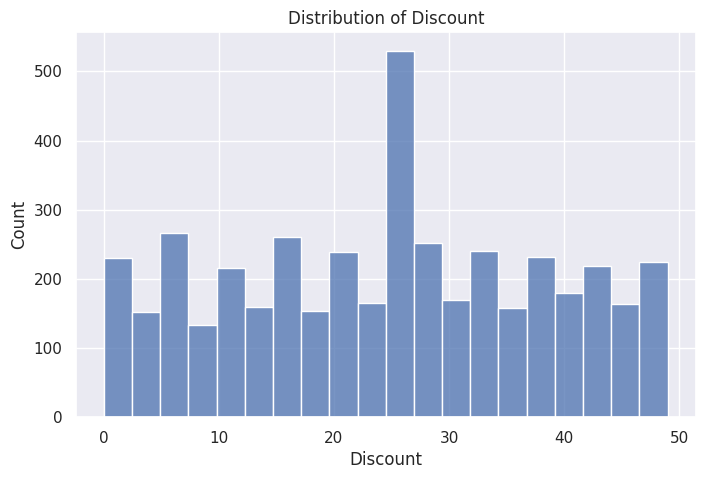

In [51]:

plt.figure(figsize=(8,5))
sns.histplot(df['Discount'], bins=20)
plt.title("Distribution of Discount")
plt.show()

**Stock distribution**

Shows how many items are available or out of stock.

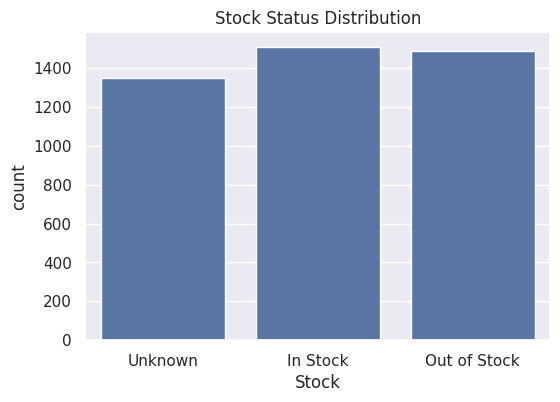

In [52]:


plt.figure(figsize=(6,4))
sns.countplot(x='Stock', data=df)
plt.title("Stock Status Distribution")
plt.show()

**Category distribution**

Shows which category is most common.

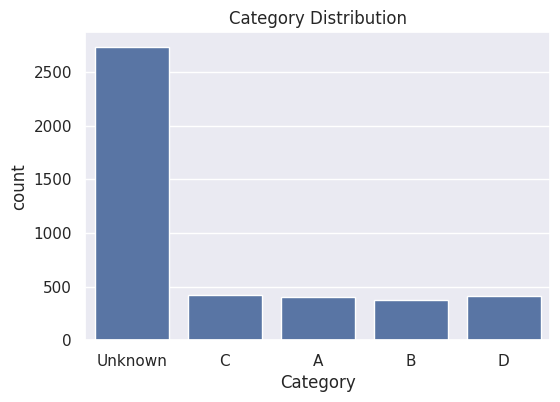

In [53]:

plt.figure(figsize=(6,4))
sns.countplot(x='Category', data=df)
plt.title("Category Distribution")
plt.show()

**Price vs Rating by Stock Status Relationship**

shows the relationship between Price and Rating, colored by Stock status, highlighting patterns between stock availability, price, and ratings.

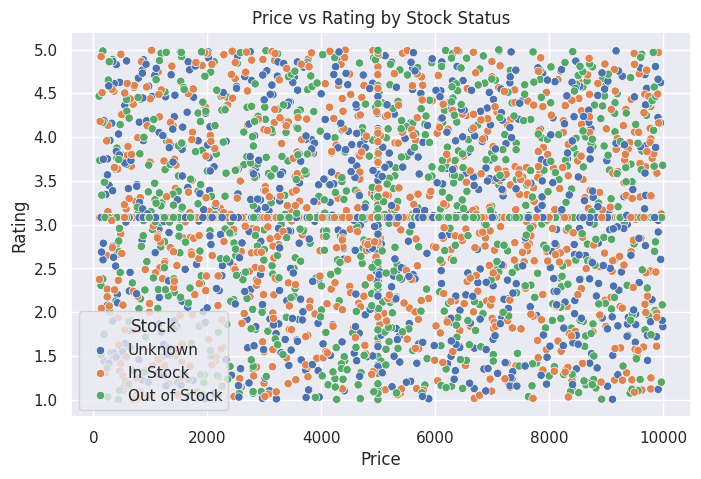

In [54]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Price', y='Rating', hue='Stock', data=df)
plt.title("Price vs Rating by Stock Status")
plt.show()


**Price vs Rating Relationship**

Examines correlation between price and rating.

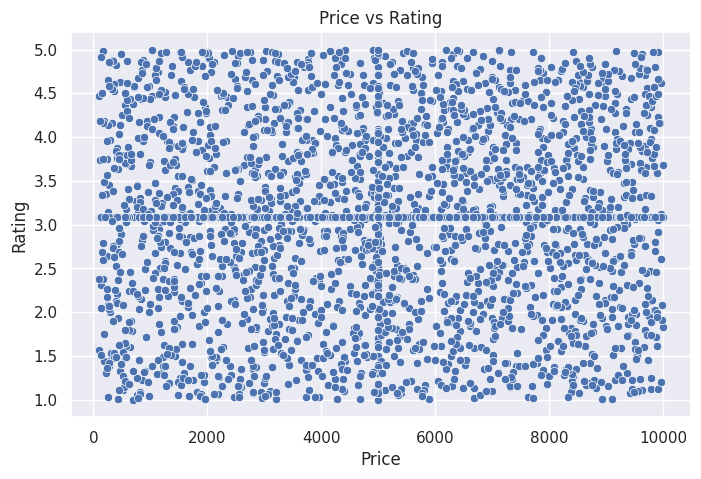

In [60]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Price', y='Rating', data=df)
plt.title("Price vs Rating")
plt.show()


**Correlation Matrix**

This heatmap shows the correlation between `Price`, `Rating`, and `Discount`, helping identify how strongly these variables are related to each other.


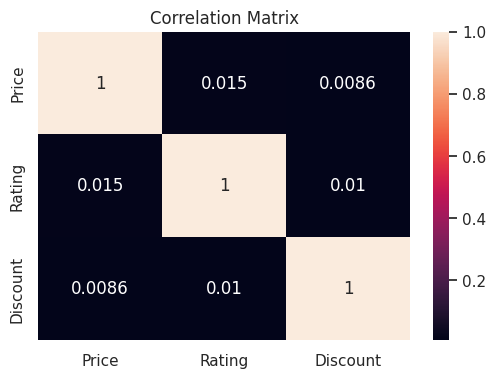

In [56]:
plt.figure(figsize=(6,4))
sns.heatmap(df[['Price','Rating','Discount']].corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

**Average Price by Category**

This bar chart shows the average `Price` for each `Category`, allowing us to compare how product prices vary across different categories.


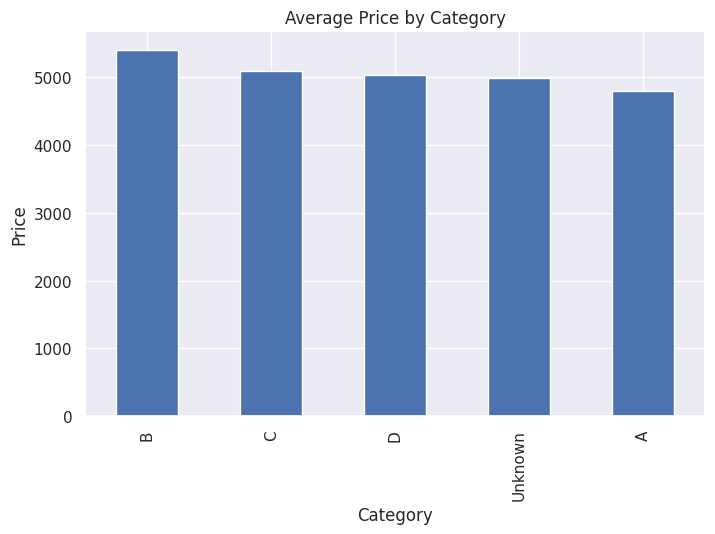

In [57]:

category_price = df.groupby('Category')['Price'].mean().sort_values(ascending=False)
plt.figure(figsize=(8,5))
category_price.plot(kind='bar')
plt.title("Average Price by Category")
plt.ylabel("Price")
plt.show()


**Average Rating by Category**

This bar chart shows the average Rating for each Category, highlighting which categories have higher or lower customer ratings

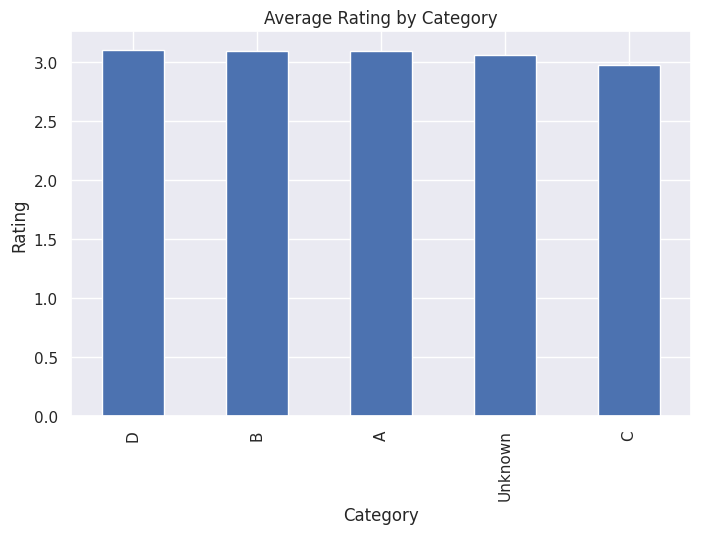

In [58]:

category_rating = df.groupby('Category')['Rating'].mean().sort_values(ascending=False)
plt.figure(figsize=(8,5))
category_rating.plot(kind='bar')
plt.title("Average Rating by Category")
plt.ylabel("Rating")
plt.show()

**Average Discount by Category**

This bar chart shows the average `Discount` for each `Category`, illustrating which product categories offer higher or lower discounts.


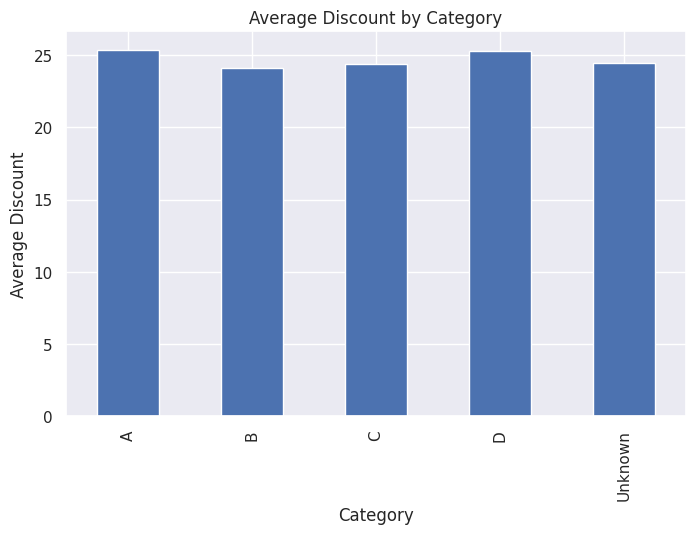

In [59]:
category_discount = df.groupby('Category')['Discount'].mean()

plt.figure(figsize=(8,5))
category_discount.plot(kind='bar')
plt.title("Average Discount by Category")
plt.ylabel("Average Discount")
plt.show()

In [61]:
df.to_csv("Retail_Product_Cleaned.csv", index=False)

# Why these visualizations were chosen:

We chose these visualizations to clearly summarize and compare key aspects of the dataset. Bar charts help show differences in averages, such as `Price`, `Rating`, and `Discount` across categories, making patterns easy to spot. The scatter plot reveals relationships between numeric variables like `Price` and `Rating` and shows how stock status relates to them. The heatmap identifies correlations between numeric features, helping to understand which variables are strongly or weakly related. Together, these plots provide a comprehensive view of the data’s distribution, trends, and relationships.


# Main Insights:

The main insights from the analysis are that some categories, like Unknown, are more frequent than others, indicating missing or uncategorized products. Prices vary widely, with a few high-priced outliers, while most products cluster around the median. Ratings are generally moderate, with no strong correlation to price. Discounts differ across categories, suggesting targeted promotions. Stock status shows that most products are in stock, but a significant number are either out of stock or unknown. Overall, these patterns reveal trends in pricing, customer feedback, and inventory that can guide business decisions.


From the results, we can learn several key things about the products and sales data. The variation in **Price** across categories highlights which products are more premium or budget-friendly. Differences in **Rating** indicate which categories are generally more favored by customers, helping identify areas of high satisfaction or potential improvement. The patterns in **Discount** show how promotional strategies differ across categories, which can guide future pricing and marketing decisions. Finally, the **Stock** status reveals potential inventory challenges, such as products frequently out of stock or uncategorized, which can inform restocking and supply chain management strategies.
